# Jupyter notebook для "Игровая статистика"



In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv('/home/jovyan/work/.env')

DB_NAME = os.getenv('dbName', 'game')
DB_USER = os.getenv('dbUser', 'game')
DB_PASSWORD = os.getenv('dbPassword', 'game')
DB_HOST = os.getenv('dbHost', 'localhost')
DB_PORT = os.getenv('dbPort', '5432')

url = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(url, pool_pre_ping=True)

q = text('SELECT "игрок", "действие", "очки", "уровень" FROM "События"')
with engine.connect() as conn:
    df = pd.read_sql(q, conn)

df.head()


,игрок,действие,очки,уровень
0,Lev,start_level,13,50
1,Borya,defeat_enemy,55,60
2,Eva,use_boost,18,43
3,Lev,finish_level,199,39
4,Diana,use_boost,12,10


## 1) Toп 10 игроков по сумме очков


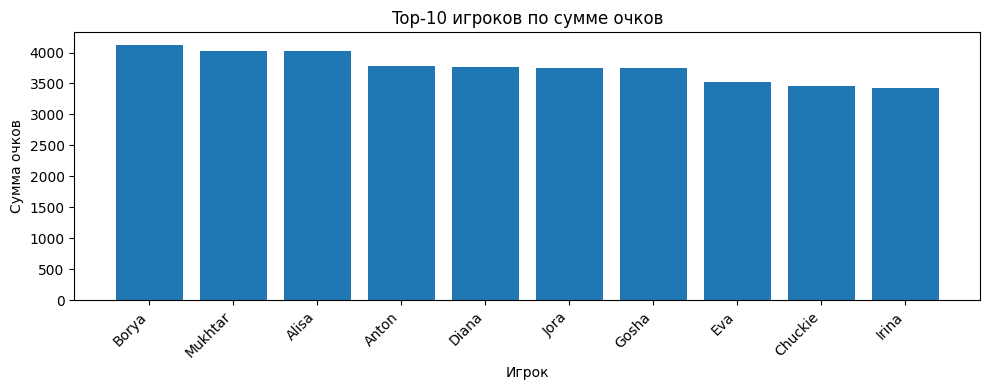

In [2]:
top_players = (
    df.groupby('игрок', as_index=False)['очки'].sum()
      .sort_values('очки', ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 4))
plt.bar(top_players['игрок'], top_players['очки'])
plt.xticks(rotation=45, ha='right')
plt.title('Top-10 игроков по сумме очков')
plt.xlabel('Игрок')
plt.ylabel('Сумма очков')
plt.tight_layout()
plt.show()


## 2) Средние очки по действию


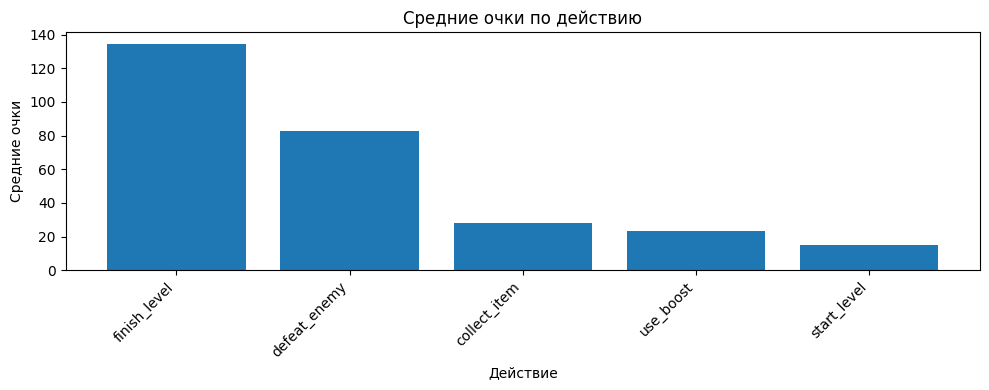

In [3]:
avg_points = (
    df.groupby('действие', as_index=False)['очки'].mean()
      .sort_values('очки', ascending=False)
)

plt.figure(figsize=(10, 4))
plt.bar(avg_points['действие'], avg_points['очки'])
plt.xticks(rotation=45, ha='right')
plt.title('Средние очки по действию')
plt.xlabel('Действие')
plt.ylabel('Средние очки')
plt.tight_layout()
plt.show()


## 3) Распределение уровней


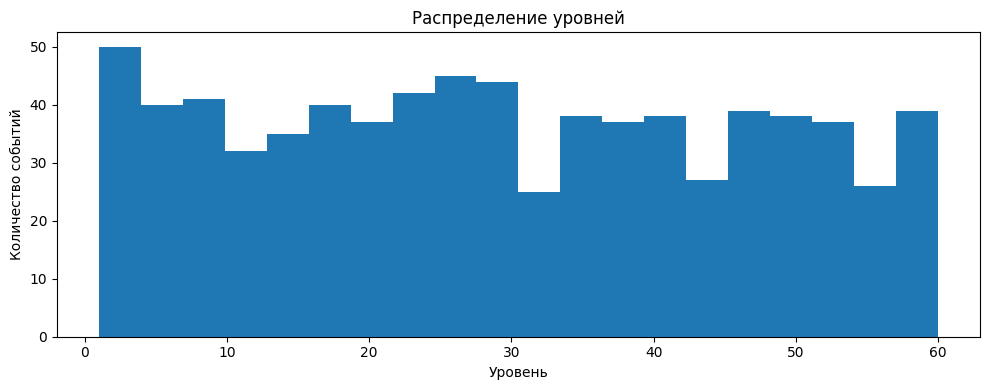

In [4]:
plt.figure(figsize=(10, 4))
plt.hist(df['уровень'], bins=20)
plt.title('Распределение уровней')
plt.xlabel('Уровень')
plt.ylabel('Количество событий')
plt.tight_layout()
plt.show()
